In [1]:
import copy
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm
from sklearn.model_selection import train_test_split

In [2]:
def show_predictions(model, X, y):

    y_predict = model(torch.tensor(X, dtype=torch.float32).unsqueeze(1))
    y_predict = y_predict.detach().numpy()
    plt.plot(y, y_predict, '.')
    plt.xlabel('Tc real')
    plt.ylabel('Tc predicted')
    plt.show()

In [3]:
def dataframe_to_sklearn_dataset(df):
    """
    Convert a pandas DataFrame into an sklearn-style regression dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with x columns:
        - first x-1 columns are features
        - last column is the target

    Returns
    -------
    dict
        sklearn-style dataset dictionary
    """

    feature_names = df.columns[:-1].tolist()
    target_name = df.columns[-1]

    data = df.iloc[:, :-1].to_numpy(dtype=float)
    target = df.iloc[:, -1].to_numpy(dtype=float)

    dataset = {
        "data": data,
        "target": target,
        "frame": None,
        "target_names": [target_name],
        "feature_names": feature_names,
    }

    return dataset

In [4]:
data = pd.read_csv(r'C:\Users\amyry\OneDrive - University of Cambridge\NanoDTC_\Coding\pml_supercond\data\raw\train.csv')
data.head()
data.columns

Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

In [5]:
data_sk = dataframe_to_sklearn_dataset(data)
print(data_sk)

{'data': array([[ 4.        , 88.9444675 , 57.86269229, ...,  1.08571429,
         0.4330127 ,  0.43705882],
       [ 5.        , 92.729214  , 58.51841614, ...,  1.12857143,
         0.63245553,  0.46860627],
       [ 4.        , 88.9444675 , 57.88524186, ...,  1.11428571,
         0.4330127 ,  0.44469664],
       ...,
       [ 2.        , 99.66319   , 95.609104  , ...,  3.2       ,
         0.5       ,  0.4       ],
       [ 2.        , 99.66319   , 97.0956022 , ...,  2.21      ,
         0.5       ,  0.46249324],
       [ 3.        , 87.46833333, 86.8585    , ...,  1.8       ,
         1.41421356,  1.5       ]], shape=(21263, 81)), 'target': array([29.  , 26.  , 19.  , ...,  1.98,  1.84, 12.8 ], shape=(21263,)), 'frame': None, 'target_names': ['critical_temp'], 'feature_names': ['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 

In [6]:
# Read data
X, y = data_sk['data'], data_sk['target']

print(X.shape)
#X = X.reshape(1,21263,81)
print(X.shape)

# Apply normalisation
X_norm = X / X.max(axis=0)
y_max = y.max()
y_norm = y / y_max
print(y_max)


# train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, train_size=0.7, shuffle=True)
print(f"Filtered Train Shape: {X_train.shape}") 
print(f"Filtered Test Shape: {X_test.shape}")

# Convert to 2D PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


(21263, 81)
(21263, 81)
185.0
Filtered Train Shape: (14884, 81)
Filtered Test Shape: (6379, 81)


In [14]:
# Define the model.
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Flatten(),
    # 81 -> conv(3) -> 79 -> pool -> 39 -> conv(3) -> 37 -> pool -> 18
    nn.Linear(32*18, 64),
    #nn.LazyLinear(64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

C:\Users\amyry\AppData\Local\Temp\ipykernel_36360\1619191001.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  bar.set_postfix(mse=float(loss))


Epoch 0: MSE = 0.0120 scaled: 409.64
Epoch 1: MSE = 0.0097 scaled: 331.76
Epoch 2: MSE = 0.0089 scaled: 306.22
Epoch 3: MSE = 0.0086 scaled: 293.80
Epoch 4: MSE = 0.0082 scaled: 281.90
Epoch 5: MSE = 0.0080 scaled: 273.15
Epoch 6: MSE = 0.0078 scaled: 265.39
Epoch 7: MSE = 0.0076 scaled: 260.02
Epoch 8: MSE = 0.0074 scaled: 254.18
Epoch 9: MSE = 0.0073 scaled: 248.73
Epoch 10: MSE = 0.0071 scaled: 244.18
Epoch 11: MSE = 0.0070 scaled: 240.45
Epoch 12: MSE = 0.0070 scaled: 238.03
Epoch 13: MSE = 0.0069 scaled: 235.87
Epoch 14: MSE = 0.0068 scaled: 233.75
Epoch 15: MSE = 0.0068 scaled: 231.67
Epoch 16: MSE = 0.0067 scaled: 230.21
Epoch 17: MSE = 0.0067 scaled: 227.80
Epoch 18: MSE = 0.0066 scaled: 225.92
Epoch 19: MSE = 0.0066 scaled: 224.57
Epoch 20: MSE = 0.0065 scaled: 222.62
Epoch 21: MSE = 0.0065 scaled: 221.07
Epoch 22: MSE = 0.0064 scaled: 219.34
Epoch 23: MSE = 0.0064 scaled: 217.84
Epoch 24: MSE = 0.0063 scaled: 216.27
Epoch 25: MSE = 0.0063 scaled: 214.91
Epoch 26: MSE = 0.0062

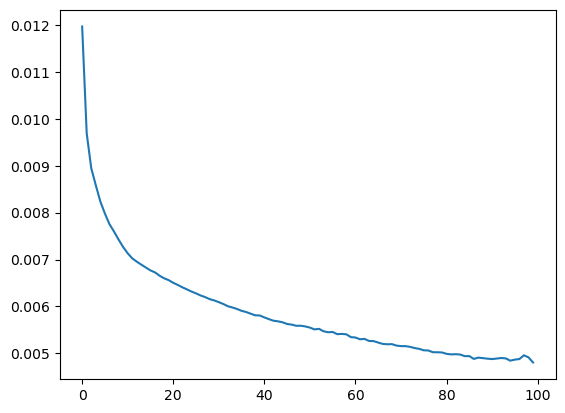

In [15]:
# loss function and optimizer
loss_fn = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.0001)
 
n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)
 
# Hold the best model
best_mse = np.inf   # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            X_batch = X_batch.unsqueeze(1)  # add channel dimension
            #print(X_batch.shape)
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    mse = loss_fn(y_pred, y_test)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: MSE = {mse:.4f}", "scaled: %.2f" % (mse * y_max**2))
 
# restore model and return best accuracy
model.load_state_dict(best_weights)
print("MSE: %.4f " % best_mse, "scaled: %.2f" % (best_mse * y_max**2))
print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
plt.plot(history)
plt.show()

MSE: 0.0048  scaled: 164.50
RMSE: 0.0693  scaled: 12.83

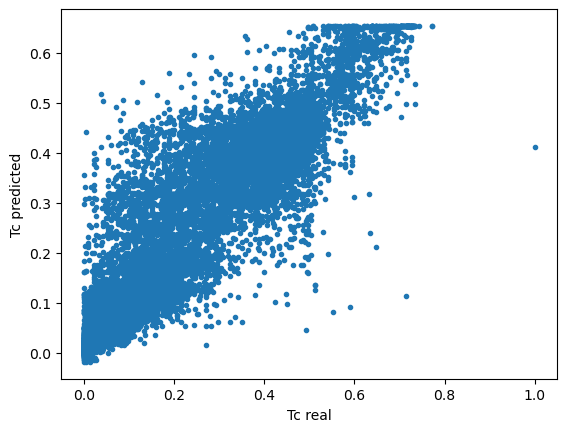

In [20]:
show_predictions(model, X_norm, y_norm)

In [21]:
def train(lr):
    model = nn.Sequential(
        nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Flatten(),
        # 81 -> conv(3) -> 79 -> pool -> 39 -> conv(3) -> 37 -> pool -> 18 -> conv(3) -> 16 -> pool -> 8
        nn.Linear(64*8, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 1)
    )

    # loss function and optimizer
    loss_fn = nn.MSELoss()  # mean square error
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    n_epochs = 100   # number of epochs to run
    batch_size = 10  # size of each batch
    batch_start = torch.arange(0, len(X_train), batch_size)
    
    # Hold the best model
    best_mse = np.inf   # init to infinity
    best_weights = None
    history = []

    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
            bar.set_description(f"Epoch {epoch}")
            for start in bar:
                # take a batch
                X_batch = X_train[start:start+batch_size]
                y_batch = y_train[start:start+batch_size]
                X_batch = X_batch.unsqueeze(1)  # add channel dimension
                #print(X_batch.shape)
                # forward pass
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                # backward pass
                optimizer.zero_grad()
                loss.backward()
                # update weights
                optimizer.step()
                # print progress
                bar.set_postfix(mse=float(loss))
        # evaluate accuracy at end of each epoch
        model.eval()
        y_pred = model(X_test)
        mse = loss_fn(y_pred, y_test)
        mse = float(mse)
        history.append(mse)
        if mse < best_mse:
            best_mse = mse
            best_weights = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch}: MSE = {mse:.4f}", "scaled: %.2f" % (mse * y_max**2))
    
    # restore model and return best accuracy
    model.load_state_dict(best_weights)
    print("MSE: %.4f " % best_mse, "scaled: %.2f" % (best_mse * y_max**2))
    print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
    plt.plot(history)
    plt.show()

    show_predictions(model, X_norm, y_norm)

Learning rate: 0.0001
Epoch 0: MSE = 0.0129 scaled: 440.51
Epoch 1: MSE = 0.0098 scaled: 336.97
Epoch 2: MSE = 0.0089 scaled: 303.96
Epoch 3: MSE = 0.0083 scaled: 285.34
Epoch 4: MSE = 0.0079 scaled: 270.42
Epoch 5: MSE = 0.0077 scaled: 262.08
Epoch 6: MSE = 0.0074 scaled: 252.58
Epoch 7: MSE = 0.0072 scaled: 244.97
Epoch 8: MSE = 0.0070 scaled: 237.92
Epoch 9: MSE = 0.0068 scaled: 232.70
Epoch 10: MSE = 0.0067 scaled: 227.83
Epoch 11: MSE = 0.0065 scaled: 223.55
Epoch 12: MSE = 0.0064 scaled: 219.43
Epoch 13: MSE = 0.0063 scaled: 216.36
Epoch 14: MSE = 0.0062 scaled: 213.21
Epoch 15: MSE = 0.0062 scaled: 211.26
Epoch 16: MSE = 0.0061 scaled: 209.47
Epoch 17: MSE = 0.0061 scaled: 208.09
Epoch 18: MSE = 0.0060 scaled: 205.63
Epoch 19: MSE = 0.0060 scaled: 203.77
Epoch 20: MSE = 0.0059 scaled: 201.43
Epoch 21: MSE = 0.0058 scaled: 199.51
Epoch 22: MSE = 0.0058 scaled: 198.75
Epoch 23: MSE = 0.0058 scaled: 198.02
Epoch 24: MSE = 0.0057 scaled: 196.67
Epoch 25: MSE = 0.0057 scaled: 195.44


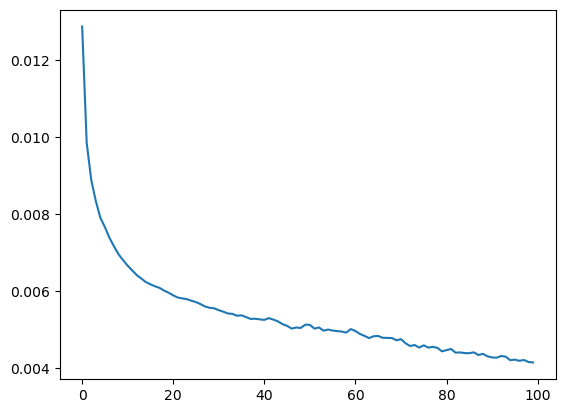

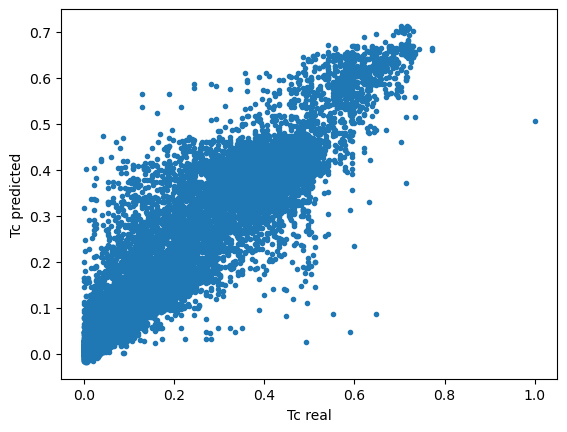

Learning rate: 0.0005
Epoch 0: MSE = 0.0102 scaled: 348.88
Epoch 1: MSE = 0.0082 scaled: 281.71
Epoch 2: MSE = 0.0070 scaled: 240.70
Epoch 3: MSE = 0.0070 scaled: 240.06
Epoch 4: MSE = 0.0067 scaled: 228.06
Epoch 5: MSE = 0.0065 scaled: 223.41
Epoch 6: MSE = 0.0063 scaled: 214.99
Epoch 7: MSE = 0.0061 scaled: 208.47
Epoch 8: MSE = 0.0060 scaled: 206.53
Epoch 9: MSE = 0.0059 scaled: 201.94
Epoch 10: MSE = 0.0057 scaled: 196.51
Epoch 11: MSE = 0.0058 scaled: 197.99
Epoch 12: MSE = 0.0057 scaled: 195.82
Epoch 13: MSE = 0.0057 scaled: 196.29
Epoch 14: MSE = 0.0055 scaled: 187.76
Epoch 15: MSE = 0.0053 scaled: 181.00
Epoch 16: MSE = 0.0052 scaled: 178.85
Epoch 17: MSE = 0.0053 scaled: 182.97
Epoch 18: MSE = 0.0052 scaled: 177.74
Epoch 19: MSE = 0.0049 scaled: 168.82
Epoch 20: MSE = 0.0052 scaled: 176.99
Epoch 21: MSE = 0.0052 scaled: 177.90
Epoch 22: MSE = 0.0051 scaled: 173.25
Epoch 23: MSE = 0.0054 scaled: 183.28
Epoch 24: MSE = 0.0052 scaled: 176.51
Epoch 25: MSE = 0.0052 scaled: 178.65


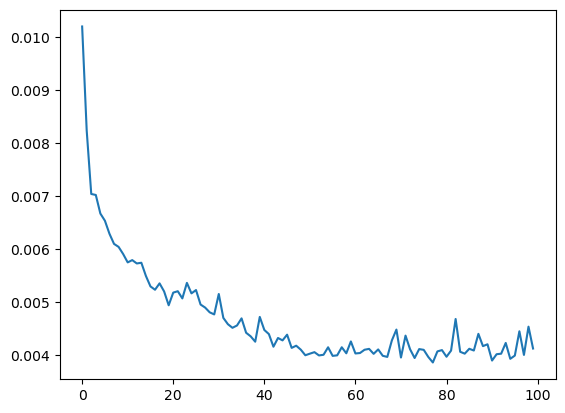

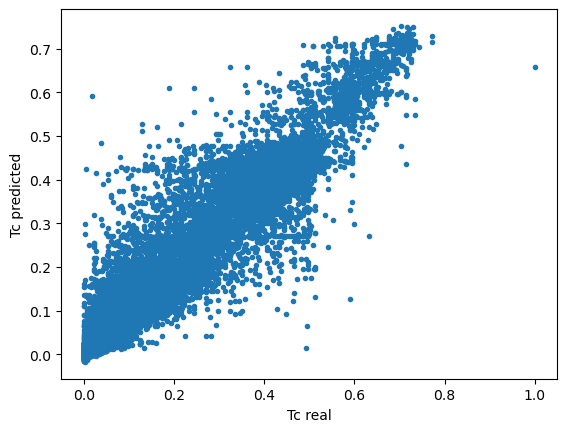

Learning rate: 0.001
Epoch 0: MSE = 0.0083 scaled: 284.31
Epoch 1: MSE = 0.0079 scaled: 269.03
Epoch 2: MSE = 0.0072 scaled: 247.82
Epoch 3: MSE = 0.0068 scaled: 232.52
Epoch 4: MSE = 0.0065 scaled: 223.94
Epoch 5: MSE = 0.0063 scaled: 214.97
Epoch 6: MSE = 0.0062 scaled: 211.66
Epoch 7: MSE = 0.0061 scaled: 208.42
Epoch 8: MSE = 0.0060 scaled: 204.08
Epoch 9: MSE = 0.0058 scaled: 199.11
Epoch 10: MSE = 0.0060 scaled: 204.86
Epoch 11: MSE = 0.0061 scaled: 207.26
Epoch 12: MSE = 0.0057 scaled: 196.38
Epoch 13: MSE = 0.0057 scaled: 196.26
Epoch 14: MSE = 0.0060 scaled: 203.76
Epoch 15: MSE = 0.0057 scaled: 196.45
Epoch 16: MSE = 0.0056 scaled: 192.32
Epoch 17: MSE = 0.0064 scaled: 217.59
Epoch 18: MSE = 0.0057 scaled: 195.38
Epoch 19: MSE = 0.0058 scaled: 197.37
Epoch 20: MSE = 0.0055 scaled: 186.70
Epoch 21: MSE = 0.0053 scaled: 180.73
Epoch 22: MSE = 0.0054 scaled: 183.51
Epoch 23: MSE = 0.0052 scaled: 178.49
Epoch 24: MSE = 0.0055 scaled: 187.48
Epoch 25: MSE = 0.0060 scaled: 204.01
E

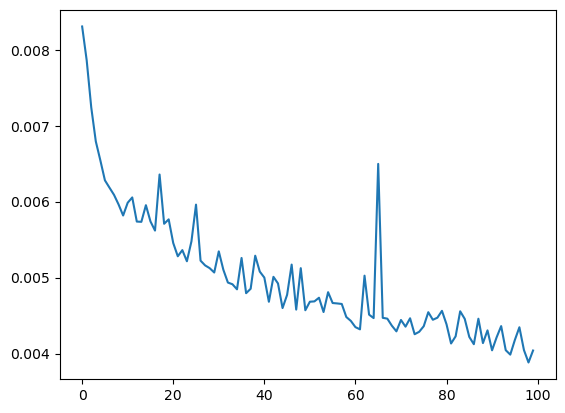

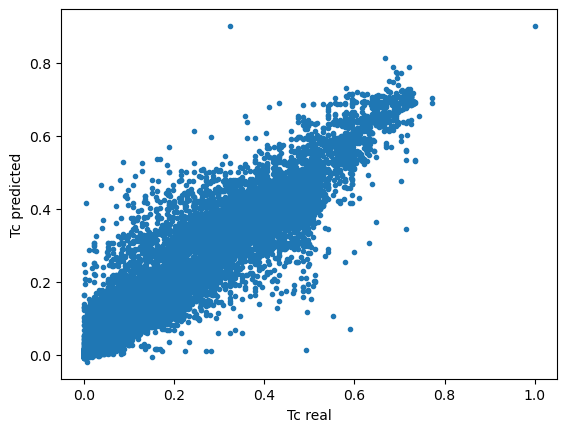

Learning rate: 0.005
Epoch 0: MSE = 0.0082 scaled: 282.10
Epoch 1: MSE = 0.0085 scaled: 290.67
Epoch 2: MSE = 0.0081 scaled: 277.44
Epoch 3: MSE = 0.0087 scaled: 298.68
Epoch 4: MSE = 0.0074 scaled: 253.58
Epoch 5: MSE = 0.0070 scaled: 240.43
Epoch 6: MSE = 0.0068 scaled: 231.36
Epoch 7: MSE = 0.0070 scaled: 238.21
Epoch 8: MSE = 0.0068 scaled: 232.49
Epoch 9: MSE = 0.0070 scaled: 238.25
Epoch 10: MSE = 0.0066 scaled: 224.96
Epoch 11: MSE = 0.0069 scaled: 237.42
Epoch 12: MSE = 0.0063 scaled: 216.39
Epoch 13: MSE = 0.0064 scaled: 218.46
Epoch 14: MSE = 0.0062 scaled: 213.68
Epoch 15: MSE = 0.0065 scaled: 223.53
Epoch 16: MSE = 0.0064 scaled: 217.96
Epoch 17: MSE = 0.0066 scaled: 227.25
Epoch 18: MSE = 0.0063 scaled: 214.05
Epoch 19: MSE = 0.0064 scaled: 218.16
Epoch 20: MSE = 0.0060 scaled: 206.53
Epoch 21: MSE = 0.0061 scaled: 210.10
Epoch 22: MSE = 0.0062 scaled: 212.34
Epoch 23: MSE = 0.0060 scaled: 206.19
Epoch 24: MSE = 0.0065 scaled: 221.59
Epoch 25: MSE = 0.0061 scaled: 209.85
E

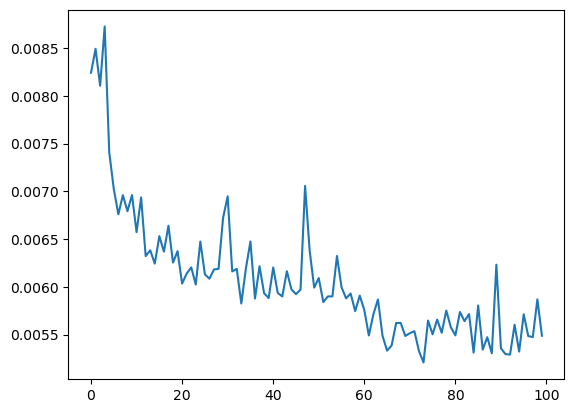

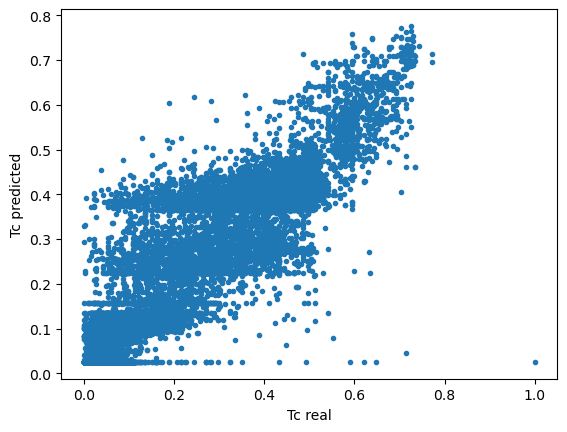

Learning rate: 0.01
Epoch 0: MSE = 0.0085 scaled: 290.84
Epoch 1: MSE = 0.0079 scaled: 268.69
Epoch 2: MSE = 0.0079 scaled: 269.67
Epoch 3: MSE = 0.0091 scaled: 310.18
Epoch 4: MSE = 0.0082 scaled: 280.53
Epoch 5: MSE = 0.0080 scaled: 275.00
Epoch 6: MSE = 0.0081 scaled: 278.34
Epoch 7: MSE = 0.0083 scaled: 285.26
Epoch 8: MSE = 0.0084 scaled: 288.97
Epoch 9: MSE = 0.0084 scaled: 286.38
Epoch 10: MSE = 0.0081 scaled: 275.86
Epoch 11: MSE = 0.0082 scaled: 281.85
Epoch 12: MSE = 0.0113 scaled: 386.72
Epoch 13: MSE = 0.0075 scaled: 255.40
Epoch 14: MSE = 0.0079 scaled: 270.85
Epoch 15: MSE = 0.0073 scaled: 250.56
Epoch 16: MSE = 0.0073 scaled: 249.31
Epoch 17: MSE = 0.0074 scaled: 251.63
Epoch 18: MSE = 0.0071 scaled: 244.00
Epoch 19: MSE = 0.0074 scaled: 253.24
Epoch 20: MSE = 0.0076 scaled: 259.57
Epoch 21: MSE = 0.0087 scaled: 299.17
Epoch 22: MSE = 0.0086 scaled: 295.11
Epoch 23: MSE = 0.0075 scaled: 256.37
Epoch 24: MSE = 0.0075 scaled: 256.85
Epoch 25: MSE = 0.0074 scaled: 254.01
Ep

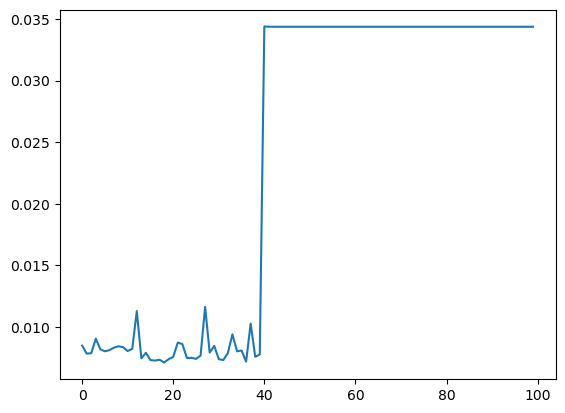

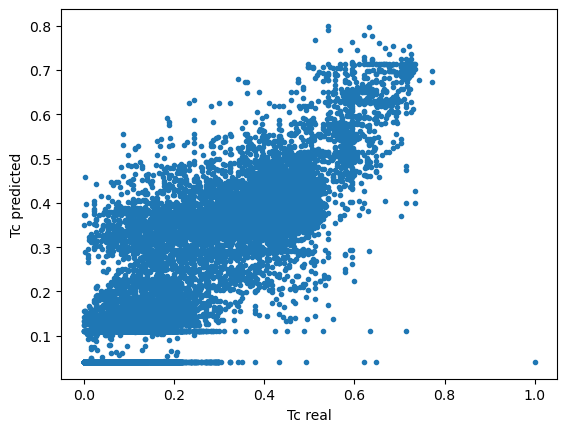

In [22]:
for lr in [0.0001, 0.0005, 0.001, 0.005, 0.01]:
    print(f"Learning rate: {lr}")
    train(lr)

# LEARNING RATE 0.0005 SELECTED
# now try different loss functions

In [11]:
def train(loss_fn):
    lr=0.0005
    model = nn.Sequential(
        nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Flatten(),
        # 81 -> conv(3) -> 79 -> pool -> 39 -> conv(3) -> 37 -> pool -> 18 -> conv(3) -> 16 -> pool -> 8
        nn.Linear(64*8, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, 1)
    )

    # loss function and optimizer
    mse_loss = nn.MSELoss()  # mean square error
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    n_epochs = 100   # number of epochs to run
    batch_size = 10  # size of each batch
    batch_start = torch.arange(0, len(X_train), batch_size)
    
    # Hold the best model
    best_lossval = np.inf   # init to infinity
    best_mse = np.inf # init to infinity
    best_weights = None
    history = []

    for epoch in range(n_epochs):
        model.train()
        with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
            bar.set_description(f"Epoch {epoch}")
            for start in bar:
                # take a batch
                X_batch = X_train[start:start+batch_size]
                y_batch = y_train[start:start+batch_size]
                X_batch = X_batch.unsqueeze(1)  # add channel dimension
                #print(X_batch.shape)
                # forward pass
                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)
                # backward pass
                optimizer.zero_grad()
                loss.backward()
                # update weights
                optimizer.step()
                # print progress
                bar.set_postfix(lossval=float(loss))
        # evaluate accuracy at end of each epoch
        model.eval()
        y_pred = model(X_test)
        lossval = loss_fn(y_pred, y_test)
        lossval = float(lossval)
        mse = float(mse_loss(y_pred, y_test))
        history.append(lossval)
        if lossval < best_lossval:
            best_lossval = lossval
            best_mse = mse
            best_weights = copy.deepcopy(model.state_dict())
        print(f"Epoch {epoch}: Loss = {lossval:.4f}, RMSE scaled = %.2f" % (np.sqrt(mse) * y_max))
    
    # restore model and return best accuracy
    model.load_state_dict(best_weights)
    print("Best Loss: %.4f " % best_lossval)
    print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
    plt.plot(history)
    plt.show()
    torch.save(model.state_dict(), str(loss_fn) + '.pth')

    show_predictions(model, X_norm, y_norm)

In [12]:
for loss_fn in [nn.MSELoss(), nn.L1Loss(),nn.HuberLoss(), nn.KLDivLoss(), nn.CTCLoss()]:
    print(f"Loss function: {loss_fn}")
    train(loss_fn)

Loss function: MSELoss()
Epoch 0: Loss = 0.0340, RMSE scaled = 34.11
Epoch 1: Loss = 0.0340, RMSE scaled = 34.11
Epoch 2: Loss = 0.0340, RMSE scaled = 34.11
Epoch 3: Loss = 0.0340, RMSE scaled = 34.11
Epoch 4: Loss = 0.0340, RMSE scaled = 34.11
Epoch 5: Loss = 0.0340, RMSE scaled = 34.11
Epoch 6: Loss = 0.0340, RMSE scaled = 34.11
Epoch 7: Loss = 0.0340, RMSE scaled = 34.11
Epoch 8: Loss = 0.0340, RMSE scaled = 34.11
Epoch 9: Loss = 0.0340, RMSE scaled = 34.11
Epoch 10: Loss = 0.0340, RMSE scaled = 34.11
Epoch 11: Loss = 0.0340, RMSE scaled = 34.11


KeyboardInterrupt: 

Epoch 0: Loss = 0.0085, RMSE scaled = 17.01
Epoch 1: Loss = 0.0076, RMSE scaled = 16.14
Epoch 2: Loss = 0.0072, RMSE scaled = 15.69
Epoch 3: Loss = 0.0070, RMSE scaled = 15.49
Epoch 4: Loss = 0.0068, RMSE scaled = 15.25
Epoch 5: Loss = 0.0067, RMSE scaled = 15.19
Epoch 6: Loss = 0.0065, RMSE scaled = 14.90
Epoch 7: Loss = 0.0061, RMSE scaled = 14.49
Epoch 8: Loss = 0.0062, RMSE scaled = 14.59
Epoch 9: Loss = 0.0062, RMSE scaled = 14.62
Epoch 10: Loss = 0.0063, RMSE scaled = 14.64
Epoch 11: Loss = 0.0063, RMSE scaled = 14.64
Epoch 12: Loss = 0.0062, RMSE scaled = 14.54
Epoch 13: Loss = 0.0062, RMSE scaled = 14.62
Epoch 14: Loss = 0.0061, RMSE scaled = 14.41
Epoch 15: Loss = 0.0060, RMSE scaled = 14.36
Epoch 16: Loss = 0.0058, RMSE scaled = 14.04
Epoch 17: Loss = 0.0058, RMSE scaled = 14.08
Epoch 18: Loss = 0.0058, RMSE scaled = 14.08
Epoch 19: Loss = 0.0056, RMSE scaled = 13.85
Epoch 20: Loss = 0.0056, RMSE scaled = 13.83
Epoch 21: Loss = 0.0057, RMSE scaled = 13.94
Epoch 22: Loss = 0.0

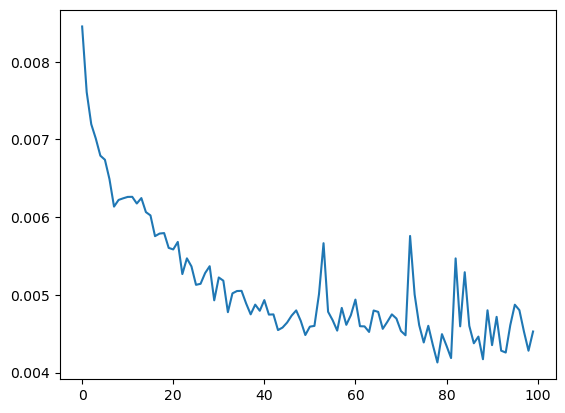

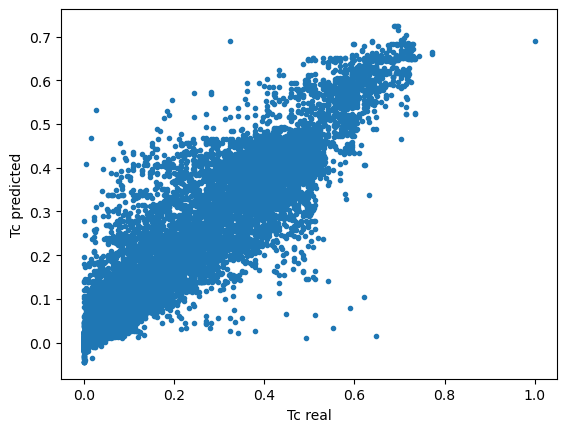

In [13]:
lr=0.0005
loss_fn = nn.MSELoss()
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Flatten(),
    # 81 -> conv(3) -> 79 -> pool -> 39 -> conv(3) -> 37 -> pool -> 18 -> conv(3) -> 16 -> pool -> 8
    nn.Linear(64*8, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

# loss function and optimizer
mse_loss = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=lr)

n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_lossval = np.inf   # init to infinity
best_mse = np.inf # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            X_batch = X_batch.unsqueeze(1)  # add channel dimension
            #print(X_batch.shape)
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(lossval=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    lossval = loss_fn(y_pred, y_test)
    lossval = float(lossval)
    mse = float(mse_loss(y_pred, y_test))
    history.append(lossval)
    if lossval < best_lossval:
        best_lossval = lossval
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: Loss = {lossval:.4f}, RMSE scaled = %.2f" % (np.sqrt(mse) * y_max))

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("Best Loss: %.4f " % best_lossval)
print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
plt.plot(history)
plt.show()
torch.save(model.state_dict(), str(loss_fn) + '.pth')

show_predictions(model, X_norm, y_norm)

Epoch 0: Loss = 0.0731, RMSE scaled = 20.19
Epoch 1: Loss = 0.0632, RMSE scaled = 17.23
Epoch 2: Loss = 0.0585, RMSE scaled = 16.51
Epoch 3: Loss = 0.0585, RMSE scaled = 16.12
Epoch 4: Loss = 0.0554, RMSE scaled = 15.21
Epoch 5: Loss = 0.0521, RMSE scaled = 15.16
Epoch 6: Loss = 0.0507, RMSE scaled = 14.62
Epoch 7: Loss = 0.0503, RMSE scaled = 15.04
Epoch 8: Loss = 0.0484, RMSE scaled = 14.18
Epoch 9: Loss = 0.0477, RMSE scaled = 14.30
Epoch 10: Loss = 0.0480, RMSE scaled = 14.34
Epoch 11: Loss = 0.0463, RMSE scaled = 14.10
Epoch 12: Loss = 0.0458, RMSE scaled = 13.99
Epoch 13: Loss = 0.0458, RMSE scaled = 14.05
Epoch 14: Loss = 0.0452, RMSE scaled = 13.94
Epoch 15: Loss = 0.0458, RMSE scaled = 13.89
Epoch 16: Loss = 0.0460, RMSE scaled = 14.38
Epoch 17: Loss = 0.0441, RMSE scaled = 13.53
Epoch 18: Loss = 0.0441, RMSE scaled = 13.56
Epoch 19: Loss = 0.0442, RMSE scaled = 13.46
Epoch 20: Loss = 0.0444, RMSE scaled = 13.54
Epoch 21: Loss = 0.0445, RMSE scaled = 13.33
Epoch 22: Loss = 0.0

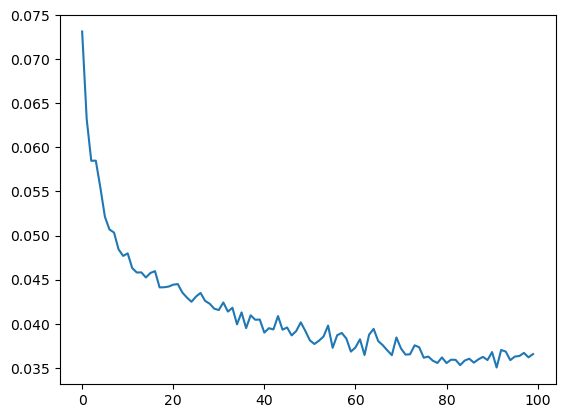

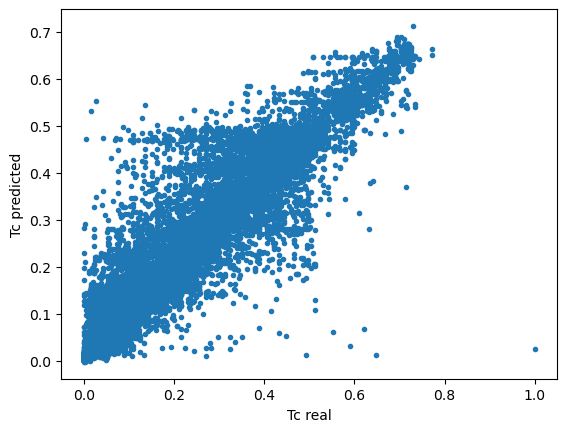

In [14]:
lr=0.0005
loss_fn = nn.L1Loss()
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Flatten(),
    # 81 -> conv(3) -> 79 -> pool -> 39 -> conv(3) -> 37 -> pool -> 18 -> conv(3) -> 16 -> pool -> 8
    nn.Linear(64*8, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

# loss function and optimizer
mse_loss = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=lr)

n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_lossval = np.inf   # init to infinity
best_mse = np.inf # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            X_batch = X_batch.unsqueeze(1)  # add channel dimension
            #print(X_batch.shape)
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(lossval=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    lossval = loss_fn(y_pred, y_test)
    lossval = float(lossval)
    mse = float(mse_loss(y_pred, y_test))
    history.append(lossval)
    if lossval < best_lossval:
        best_lossval = lossval
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: Loss = {lossval:.4f}, RMSE scaled = %.2f" % (np.sqrt(mse) * y_max))

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("Best Loss: %.4f " % best_lossval)
print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
plt.plot(history)
plt.show()
torch.save(model.state_dict(), str(loss_fn) + '.pth')

show_predictions(model, X_norm, y_norm)

Epoch 0: Loss = 0.0061, RMSE scaled = 20.41
Epoch 1: Loss = 0.0042, RMSE scaled = 17.05
Epoch 2: Loss = 0.0039, RMSE scaled = 16.42
Epoch 3: Loss = 0.0039, RMSE scaled = 16.24
Epoch 4: Loss = 0.0037, RMSE scaled = 16.02
Epoch 5: Loss = 0.0035, RMSE scaled = 15.56
Epoch 6: Loss = 0.0034, RMSE scaled = 15.20
Epoch 7: Loss = 0.0031, RMSE scaled = 14.64
Epoch 8: Loss = 0.0031, RMSE scaled = 14.49
Epoch 9: Loss = 0.0030, RMSE scaled = 14.28
Epoch 10: Loss = 0.0030, RMSE scaled = 14.25
Epoch 11: Loss = 0.0029, RMSE scaled = 14.13
Epoch 12: Loss = 0.0029, RMSE scaled = 14.01
Epoch 13: Loss = 0.0028, RMSE scaled = 13.89
Epoch 14: Loss = 0.0028, RMSE scaled = 13.79
Epoch 15: Loss = 0.0028, RMSE scaled = 13.85
Epoch 16: Loss = 0.0027, RMSE scaled = 13.60
Epoch 17: Loss = 0.0027, RMSE scaled = 13.67
Epoch 18: Loss = 0.0027, RMSE scaled = 13.58
Epoch 19: Loss = 0.0026, RMSE scaled = 13.44
Epoch 20: Loss = 0.0026, RMSE scaled = 13.38
Epoch 21: Loss = 0.0026, RMSE scaled = 13.32
Epoch 22: Loss = 0.0

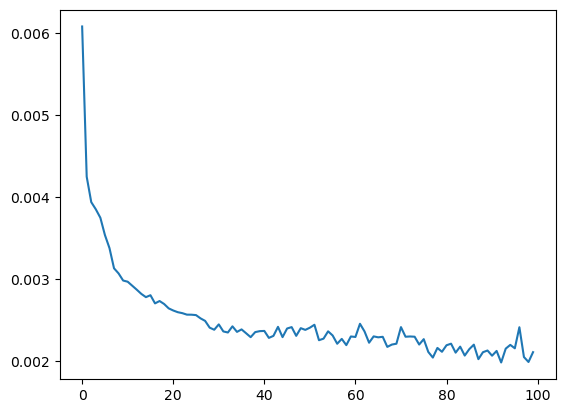

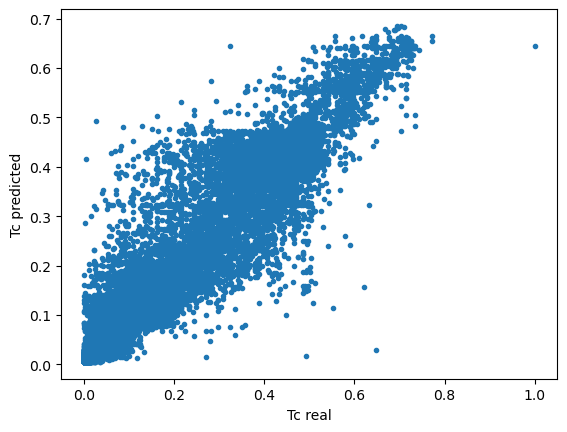

In [15]:
lr=0.0005
loss_fn = nn.HuberLoss()
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Flatten(),
    # 81 -> conv(3) -> 79 -> pool -> 39 -> conv(3) -> 37 -> pool -> 18 -> conv(3) -> 16 -> pool -> 8
    nn.Linear(64*8, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

# loss function and optimizer
mse_loss = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=lr)

n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_lossval = np.inf   # init to infinity
best_mse = np.inf # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            X_batch = X_batch.unsqueeze(1)  # add channel dimension
            #print(X_batch.shape)
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(lossval=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    lossval = loss_fn(y_pred, y_test)
    lossval = float(lossval)
    mse = float(mse_loss(y_pred, y_test))
    history.append(lossval)
    if lossval < best_lossval:
        best_lossval = lossval
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: Loss = {lossval:.4f}, RMSE scaled = %.2f" % (np.sqrt(mse) * y_max))

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("Best Loss: %.4f " % best_lossval)
print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
plt.plot(history)
plt.show()
torch.save(model.state_dict(), str(loss_fn) + '.pth')

show_predictions(model, X_norm, y_norm)

c:\Users\amyry\.conda\envs\pml_supercond\Lib\site-packages\torch\nn\modules\loss.py:558: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  return F.kl_div(


Epoch 0: Loss = -127732654538752.0000, RMSE scaled = 123015775697698960.00
Epoch 1: Loss = -31303937856372736.0000, RMSE scaled = 30137429777220231168.00
Epoch 2: Loss = -548724678139576320.0000, RMSE scaled = inf
Epoch 3: Loss = -3759900682581180416.0000, RMSE scaled = inf
Epoch 4: Loss = -16136625063775436800.0000, RMSE scaled = inf
Epoch 5: Loss = -52461367731983220736.0000, RMSE scaled = inf
Epoch 6: Loss = -141899214749050077184.0000, RMSE scaled = inf
Epoch 7: Loss = -336627746597295357952.0000, RMSE scaled = inf
Epoch 8: Loss = -723613196115475693568.0000, RMSE scaled = inf
Epoch 9: Loss = -1361416915993359286272.0000, RMSE scaled = inf
Epoch 10: Loss = -2343227248983008083968.0000, RMSE scaled = inf
Epoch 11: Loss = -3859863259408481910784.0000, RMSE scaled = inf
Epoch 12: Loss = -6134765694757210423296.0000, RMSE scaled = inf
Epoch 13: Loss = -9138090185461027831808.0000, RMSE scaled = inf
Epoch 14: Loss = -12860197620942477721600.0000, RMSE scaled = inf
Epoch 15: Loss = -1749

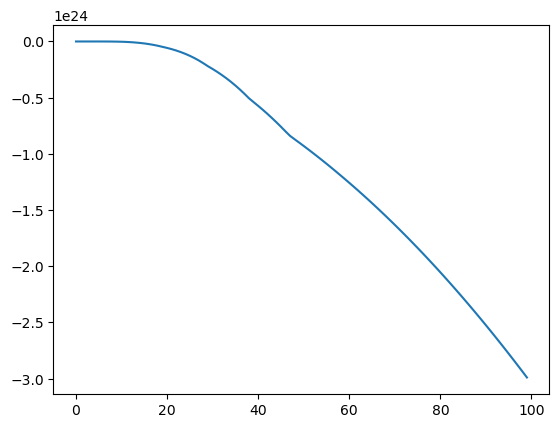

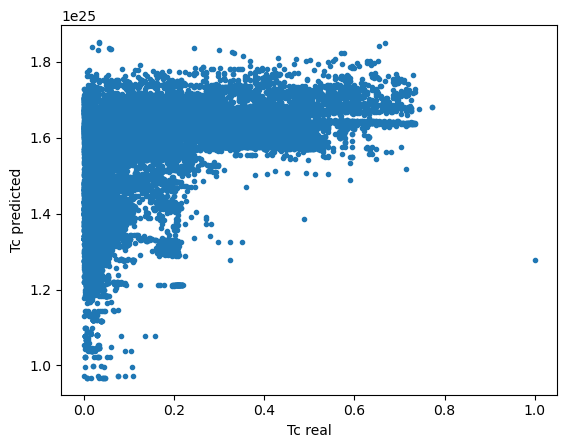

In [16]:
lr=0.0005
loss_fn = nn.KLDivLoss()
model = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),
    nn.Flatten(),
    # 81 -> conv(3) -> 79 -> pool -> 39 -> conv(3) -> 37 -> pool -> 18 -> conv(3) -> 16 -> pool -> 8
    nn.Linear(64*8, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

# loss function and optimizer
mse_loss = nn.MSELoss()  # mean square error
optimizer = optim.Adam(model.parameters(), lr=lr)

n_epochs = 100   # number of epochs to run
batch_size = 10  # size of each batch
batch_start = torch.arange(0, len(X_train), batch_size)

# Hold the best model
best_lossval = np.inf   # init to infinity
best_mse = np.inf # init to infinity
best_weights = None
history = []

for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train[start:start+batch_size]
            y_batch = y_train[start:start+batch_size]
            X_batch = X_batch.unsqueeze(1)  # add channel dimension
            #print(X_batch.shape)
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(lossval=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test)
    lossval = loss_fn(y_pred, y_test)
    lossval = float(lossval)
    mse = float(mse_loss(y_pred, y_test))
    history.append(lossval)
    if lossval < best_lossval:
        best_lossval = lossval
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())
    print(f"Epoch {epoch}: Loss = {lossval:.4f}, RMSE scaled = %.2f" % (np.sqrt(mse) * y_max))

# restore model and return best accuracy
model.load_state_dict(best_weights)
print("Best Loss: %.4f " % best_lossval)
print("RMSE: %.4f " % np.sqrt(best_mse), "scaled: %.2f" % (np.sqrt(best_mse) * y_max))
plt.plot(history)
plt.show()
torch.save(model.state_dict(), str(loss_fn) + '.pth')

show_predictions(model, X_norm, y_norm)